# Online Shoppers Purchase Prediction

## Exploratory Data Analysis and Data Preprocessing

### Objective

The objective of this project is to predict whether an online shopping session will result in a purchase.

Target Variable:

- False → No Purchase
- True → Purchase

This notebook performs:

1. Dataset Loading
2. Dataset Understanding
3. Missing Value Analysis
4. Duplicate Analysis
5. Data Distribution Analysis
6. Correlation Analysis
7. Target Analysis
8. Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.3f" % x)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
DATA_PATH = "../data/online_shoppers_intention.csv"

OUTPUT_PATH = "../outputs"
FIGURE_PATH = "../outputs/figures"

os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(FIGURE_PATH, exist_ok=True)

print("Project paths configured successfully.")

Project paths configured successfully.


In [3]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Dataset Shape: {df.shape}")

Dataset loaded successfully.
Dataset Shape: (12330, 18)


In [4]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.000,0,0.000,1,0.000,0.200,0.200,0.000,0.000,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.000,0,0.000,2,64.000,0.000,0.100,0.000,0.000,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.000,0,0.000,1,0.000,0.200,0.200,0.000,0.000,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.000,0,0.000,2,2.667,0.050,0.140,0.000,0.000,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.000,0,0.000,10,627.500,0.020,0.050,0.000,0.000,Feb,3,3,1,4,Returning_Visitor,True,False


In [5]:
print("DATASET INFORMATION")
print("-" * 50)

print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print(f"\nNumerical Features: {len(numerical_columns)}")
print(f"Categorical Features: {len(categorical_columns)}")

print("\nNumerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

DATASET INFORMATION
--------------------------------------------------
Total Rows: 12330
Total Columns: 18

Numerical Features: 14
Categorical Features: 4

Numerical Columns:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Categorical Columns:
['Month', 'VisitorType', 'Weekend', 'Revenue']


In [6]:
dataset_summary = pd.DataFrame({
    "Information": [
        "Total Rows",
        "Total Columns",
        "Numerical Features",
        "Categorical Features",
        "Target Column"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        len(numerical_columns),
        len(categorical_columns),
        "Revenue"
    ]
})

dataset_summary

,Information,Value
0,Total Rows,12330
1,Total Columns,18
2,Numerical Features,14
3,Categorical Features,4
4,Target Column,Revenue


In [7]:
data_types = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Unique Values": [df[col].nunique() for col in df.columns]
})

data_types

,Column,Data Type,Unique Values
Administrative,Administrative,int64,27
Administrative_Duration,Administrative_Duration,float64,3335
Informational,Informational,int64,17
Informational_Duration,Informational_Duration,float64,1258
ProductRelated,ProductRelated,int64,311
ProductRelated_Duration,ProductRelated_Duration,float64,9551
BounceRates,BounceRates,float64,1872
ExitRates,ExitRates,float64,4777
PageValues,PageValues,float64,2704
SpecialDay,SpecialDay,float64,6


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.000,2.315,3.322,0.000,0.000,1.000,4.000,27.000
Administrative_Duration,12330.000,80.819,176.779,0.000,0.000,7.500,93.256,3398.750
Informational,12330.000,0.504,1.270,0.000,0.000,0.000,0.000,24.000
Informational_Duration,12330.000,34.472,140.749,0.000,0.000,0.000,0.000,2549.375
ProductRelated,12330.000,31.731,44.476,0.000,7.000,18.000,38.000,705.000
ProductRelated_Duration,12330.000,1194.746,1913.669,0.000,184.137,598.937,1464.157,63973.522
BounceRates,12330.000,0.022,0.048,0.000,0.000,0.003,0.017,0.200
ExitRates,12330.000,0.043,0.049,0.000,0.014,0.025,0.050,0.200
PageValues,12330.000,5.889,18.568,0.000,0.000,0.000,0.000,361.764
SpecialDay,12330.000,0.061,0.199,0.000,0.000,0.000,0.000,1.000


In [9]:
missing_values = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_values = missing_values.sort_values(
    by="Missing Values",
    ascending=False
)

missing_values

,Column,Missing Values,Missing Percentage
Administrative,Administrative,0,0.000
Administrative_Duration,Administrative_Duration,0,0.000
Informational,Informational,0,0.000
Informational_Duration,Informational_Duration,0,0.000
ProductRelated,ProductRelated,0,0.000
ProductRelated_Duration,ProductRelated_Duration,0,0.000
BounceRates,BounceRates,0,0.000
ExitRates,ExitRates,0,0.000
PageValues,PageValues,0,0.000
SpecialDay,SpecialDay,0,0.000


In [10]:
total_missing = df.isnull().sum().sum()

print("MISSING VALUE ANALYSIS")
print("-" * 50)

if total_missing == 0:
    print("No missing values found in the dataset.")
else:
    print(f"Total missing values: {total_missing}")

MISSING VALUE ANALYSIS
--------------------------------------------------
No missing values found in the dataset.


In [11]:
duplicate_count = df.duplicated().sum()

duplicate_summary = pd.DataFrame({
    "Check": [
        "Total Records",
        "Duplicate Records",
        "Duplicate Percentage"
    ],
    "Value": [
        len(df),
        duplicate_count,
        round((duplicate_count / len(df)) * 100, 2)
    ]
})

duplicate_summary

,Check,Value
0,Total Records,12330.000
1,Duplicate Records,125.000
2,Duplicate Percentage,1.010


In [12]:
initial_rows = len(df)

df = df.drop_duplicates()

final_rows = len(df)

print("DUPLICATE REMOVAL")
print("-" * 50)

print(f"Rows Before Removing Duplicates: {initial_rows}")
print(f"Rows After Removing Duplicates: {final_rows}")
print(f"Duplicates Removed: {initial_rows - final_rows}")

DUPLICATE REMOVAL
--------------------------------------------------
Rows Before Removing Duplicates: 12330
Rows After Removing Duplicates: 12205
Duplicates Removed: 125


In [13]:
print("INCORRECT DATA CHECK")
print("-" * 50)

negative_values = {}

for column in numerical_columns:
    
    negative_count = (df[column] < 0).sum()
    
    negative_values[column] = negative_count

invalid_value_table = pd.DataFrame(
    list(negative_values.items()),
    columns=["Column", "Negative Values"]
)

invalid_value_table

INCORRECT DATA CHECK
--------------------------------------------------


,Column,Negative Values
0,Administrative,0
1,Administrative_Duration,0
2,Informational,0
3,Informational_Duration,0
4,ProductRelated,0
5,ProductRelated_Duration,0
6,BounceRates,0
7,ExitRates,0
8,PageValues,0
9,SpecialDay,0


In [14]:
print("Target Variable Unique Values:")
print(df["Revenue"].value_counts())

Target Variable Unique Values:
Revenue
False    10297
True      1908
Name: count, dtype: int64


In [15]:
target_counts = df["Revenue"].value_counts()

target_percentage = (
    df["Revenue"]
    .value_counts(normalize=True) * 100
)

target_analysis = pd.DataFrame({
    "Class": target_counts.index,
    "Count": target_counts.values,
    "Percentage": target_percentage.values
})

target_analysis

,Class,Count,Percentage
0,False,10297,84.367
1,True,1908,15.633


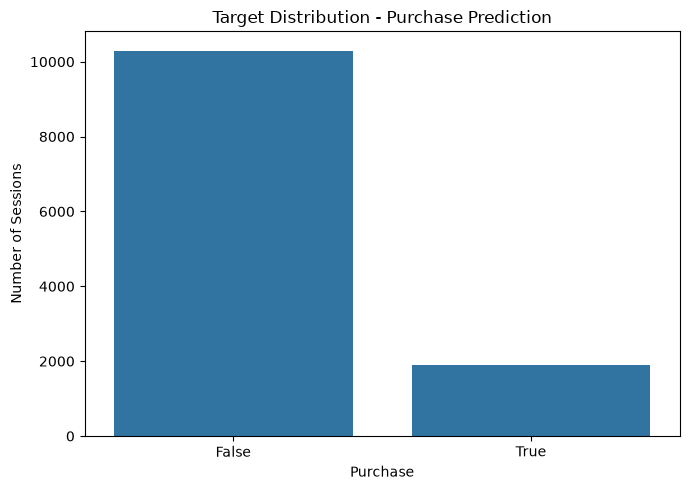

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Revenue"
)

plt.title("Target Distribution - Purchase Prediction")
plt.xlabel("Purchase")
plt.ylabel("Number of Sessions")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/target_distribution.png",
    dpi=300
)

plt.show()

In [17]:
purchase_percentage = (
    df["Revenue"].mean() * 100
)

print("TARGET ANALYSIS")
print("-" * 50)

print(f"Purchase Sessions: {purchase_percentage:.2f}%")
print(f"Non-Purchase Sessions: {100 - purchase_percentage:.2f}%")

if purchase_percentage < 40:
    print("\nThe dataset shows class imbalance.")
    print("Therefore Stratified Splitting and ROC-AUC evaluation will be used.")

TARGET ANALYSIS
--------------------------------------------------
Purchase Sessions: 15.63%
Non-Purchase Sessions: 84.37%

The dataset shows class imbalance.
Therefore Stratified Splitting and ROC-AUC evaluation will be used.


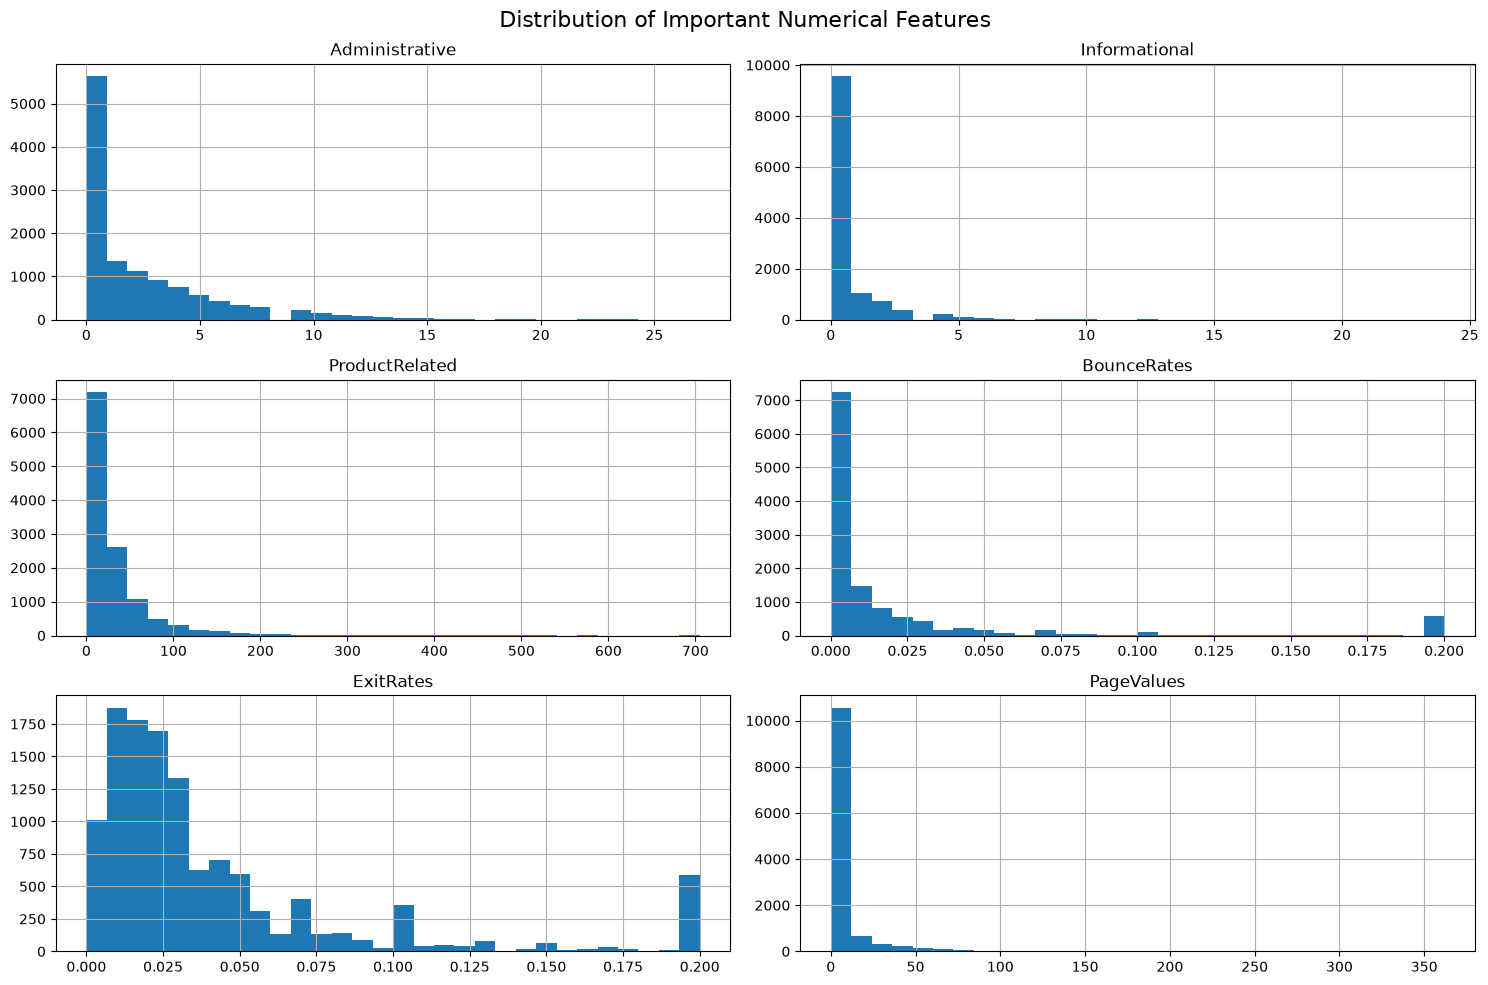

In [18]:
important_features = [
    "Administrative",
    "Informational",
    "ProductRelated",
    "BounceRates",
    "ExitRates",
    "PageValues"
]

df[important_features].hist(
    figsize=(15, 10),
    bins=30
)

plt.suptitle(
    "Distribution of Important Numerical Features",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/feature_distribution.png",
    dpi=300
)

plt.show()

In [19]:
numerical_df = df.select_dtypes(include=np.number)

correlation_matrix = numerical_df.corr()

correlation_matrix.round(2)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
Administrative,1.000,0.600,0.380,0.250,0.430,0.370,-0.210,-0.310,0.100,-0.100,-0.010,-0.030,-0.010,-0.030
Administrative_Duration,0.600,1.000,0.300,0.240,0.290,0.350,-0.140,-0.200,0.070,-0.070,-0.010,-0.020,-0.010,-0.010
Informational,0.380,0.300,1.000,0.620,0.370,0.390,-0.110,-0.160,0.050,-0.050,-0.010,-0.040,-0.030,-0.040
Informational_Duration,0.250,0.240,0.620,1.000,0.280,0.350,-0.070,-0.100,0.030,-0.030,-0.010,-0.020,-0.030,-0.030
ProductRelated,0.430,0.290,0.370,0.280,1.000,0.860,-0.190,-0.290,0.050,-0.030,0.000,-0.010,-0.040,-0.040
ProductRelated_Duration,0.370,0.350,0.390,0.350,0.860,1.000,-0.170,-0.250,0.050,-0.040,0.000,-0.010,-0.030,-0.040
BounceRates,-0.210,-0.140,-0.110,-0.070,-0.190,-0.170,1.000,0.900,-0.120,0.090,0.030,-0.020,0.000,0.090
ExitRates,-0.310,-0.200,-0.160,-0.100,-0.290,-0.250,0.900,1.000,-0.170,0.120,0.020,-0.000,-0.000,0.090
PageValues,0.100,0.070,0.050,0.030,0.050,0.050,-0.120,-0.170,1.000,-0.060,0.020,0.050,0.010,0.010
SpecialDay,-0.100,-0.070,-0.050,-0.030,-0.030,-0.040,0.090,0.120,-0.060,1.000,0.010,0.000,-0.020,0.050


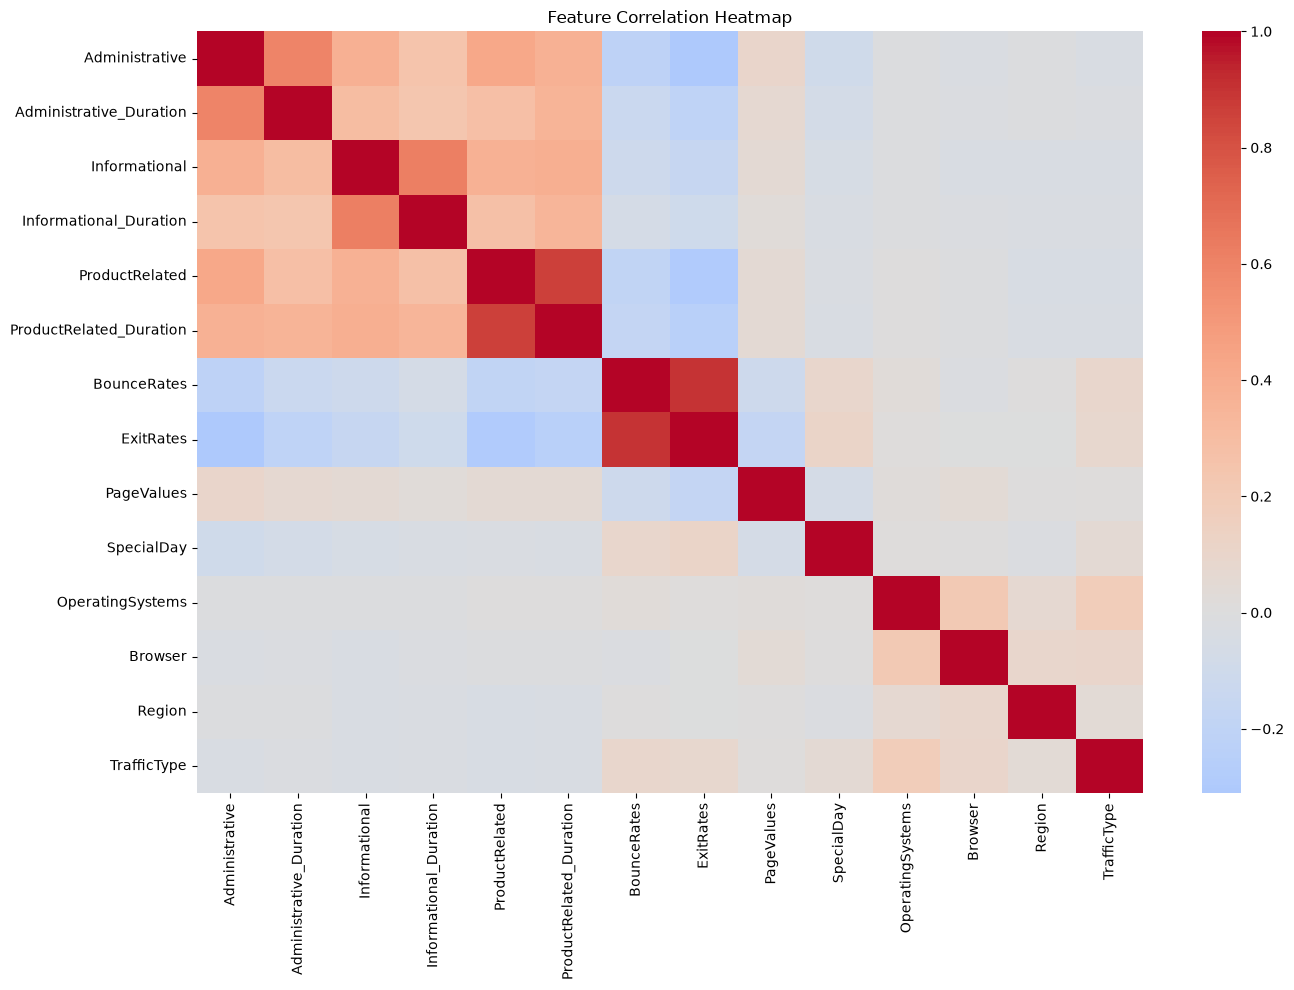

In [20]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_PATH}/correlation_heatmap.png",
    dpi=300
)

plt.show()

In [21]:
correlation_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

correlation_pairs.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

correlation_pairs["Absolute Correlation"] = (
    correlation_pairs["Correlation"].abs()
)

high_correlation = correlation_pairs.sort_values(
    by="Absolute Correlation",
    ascending=False
)

high_correlation.head(15)

,Feature 1,Feature 2,Correlation,Absolute Correlation
91,BounceRates,ExitRates,0.902,0.902
61,ProductRelated,ProductRelated_Duration,0.860,0.860
31,Informational,Informational_Duration,0.619,0.619
1,Administrative,Administrative_Duration,0.600,0.600
4,Administrative,ProductRelated,0.428,0.428
33,Informational,ProductRelated_Duration,0.386,0.386
2,Administrative,Informational,0.375,0.375
32,Informational,ProductRelated,0.373,0.373
5,Administrative,ProductRelated_Duration,0.371,0.371
19,Administrative_Duration,ProductRelated_Duration,0.354,0.354


In [22]:
categorical_columns = df.select_dtypes(
    exclude=np.number
).columns.tolist()

categorical_columns

['Month', 'VisitorType', 'Weekend', 'Revenue']

In [23]:
categorical_summary = []

for column in categorical_columns:
    
    categorical_summary.append({
        "Column": column,
        "Unique Values": df[column].nunique(),
        "Most Common Value": df[column].mode()[0]
    })

categorical_summary = pd.DataFrame(categorical_summary)

categorical_summary

,Column,Unique Values,Most Common Value
0,Month,10,May
1,VisitorType,3,Returning_Visitor
2,Weekend,2,False
3,Revenue,2,False


In [24]:
cleaning_summary = pd.DataFrame({
    "Step": [
        "Missing Values",
        "Duplicate Removal",
        "Incorrect Data Check"
    ],
    
    "Status": [
        "Completed",
        "Completed",
        "Completed"
    ],
    
    "Result": [
        f"{df.isnull().sum().sum()} missing values found",
        f"{initial_rows - final_rows} duplicates removed",
        "Negative value validation completed"
    ]
})

cleaning_summary

,Step,Status,Result
0,Missing Values,Completed,0 missing values found
1,Duplicate Removal,Completed,125 duplicates removed
2,Incorrect Data Check,Completed,Negative value validation completed


In [25]:
cleaned_data_path = "../outputs/cleaned_data.csv"

df.to_csv(
    cleaned_data_path,
    index=False
)

print("Cleaned dataset saved successfully.")
print(f"Location: {cleaned_data_path}")

Cleaned dataset saved successfully.
Location: ../outputs/cleaned_data.csv


In [26]:
print("=" * 60)
print("NOTEBOOK 01 COMPLETED")
print("=" * 60)

print("\nKey Findings:")

print(f"1. Final Dataset Shape: {df.shape}")

print(f"2. Missing Values: {df.isnull().sum().sum()}")

print(f"3. Duplicates Removed: {initial_rows - final_rows}")

print(f"4. Target Purchase Percentage: {purchase_percentage:.2f}%")

print("\nNext Step:")
print("Feature Engineering and Preprocessing")

NOTEBOOK 01 COMPLETED

Key Findings:
1. Final Dataset Shape: (12205, 18)
2. Missing Values: 0
3. Duplicates Removed: 125
4. Target Purchase Percentage: 15.63%

Next Step:
Feature Engineering and Preprocessing
